# Model Evaluation and Comparison

This notebook is used to evaluate and compare all trained YOLO11 instance segmentation models.

All models are evaluated using the **same held-out test dataset** to ensure a fair comparison.

The current experiments are:

| Model | Dataset | Segmentation Loss |
|---|---|---|
| Model A | Original dataset | BCE |
| Model B | Original dataset | Dice Loss |

Future experiments involving color and brightness augmentation will also be added to this notebook.

The main evaluation metrics are:

- Mask Precision
- Mask Recall
- Mask mAP@50
- Mask mAP@50–95
- Bounding Box Precision
- Bounding Box Recall
- Bounding Box mAP@50
- Bounding Box mAP@50–95

The same test split, image size, and evaluation configuration are used for every model.

In [1]:
# ============================================================
# CELL 1 — SETUP MODEL EVALUATION ENVIRONMENT
# ============================================================

from pathlib import Path
from ultralytics import YOLO
import torch
import pandas as pd

# ------------------------------------------------------------
# PROJECT PATHS
# ------------------------------------------------------------

project_path = Path(r"G:\AIIC")

segmentation_project = (
    project_path
    / "yolo_segmentation"
)

data_yaml = (
    segmentation_project
    / "dataset"
    / "data.yaml"
)

runs_path = (
    segmentation_project
    / "runs"
)

evaluation_path = (
    segmentation_project
    / "evaluation"
)

evaluation_path.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# MODEL PATHS
# ------------------------------------------------------------

bce_model_path = (
    runs_path
    / "yolo11n_seg_aiic"
    / "weights"
    / "best.pt"
)

dice_model_path = (
    runs_path
    / "yolo11n_seg_aiic_dice_original"
    / "weights"
    / "best.pt"
)


# ------------------------------------------------------------
# ENVIRONMENT CHECK
# ------------------------------------------------------------

print("=" * 70)
print("MODEL EVALUATION — SETUP CHECK")
print("=" * 70)

print(f"Dataset YAML      : {data_yaml}")
print(f"Dataset exists    : {data_yaml.exists()}")

print()
print(f"BCE model         : {bce_model_path}")
print(f"BCE model exists  : {bce_model_path.exists()}")

print()
print(f"Dice model        : {dice_model_path}")
print(f"Dice model exists : {dice_model_path.exists()}")

print()
print(f"CUDA available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU               : {torch.cuda.get_device_name(0)}")

print()
print(f"Evaluation folder : {evaluation_path}")

print("=" * 70)

MODEL EVALUATION — SETUP CHECK
Dataset YAML      : G:\AIIC\yolo_segmentation\dataset\data.yaml
Dataset exists    : True

BCE model         : G:\AIIC\yolo_segmentation\runs\yolo11n_seg_aiic\weights\best.pt
BCE model exists  : True

Dice model        : G:\AIIC\yolo_segmentation\runs\yolo11n_seg_aiic_dice_original\weights\best.pt
Dice model exists : True

CUDA available    : True
GPU               : NVIDIA GeForce RTX 5060

Evaluation folder : G:\AIIC\yolo_segmentation\evaluation


## 2. Evaluate BCE and Dice Models on the Same Test Set

Both trained models are evaluated using the same held-out test dataset.

The models evaluated are:

- **Model A:** YOLO11n-Seg with BCE mask loss
- **Model B:** YOLO11n-Seg with Dice mask loss

To ensure a fair comparison, both models use the same:

- Test split
- Image size: 640 × 640
- Batch size: 8
- GPU device
- 109 inventory classes

The primary comparison focuses on prediction-based metrics:

- Precision
- Recall
- mAP@50
- mAP@50–95

These metrics are calculated separately for bounding boxes and segmentation masks.

> **Note:** The custom Dice Loss function was required during training only. It is not required for inference-based evaluation metrics such as Precision, Recall, and mAP.

In [2]:
# ============================================================
# CELL 2 — EVALUATE BCE MODEL
# SAME HELD-OUT TEST SET
# ============================================================

print("=" * 70)
print("MODEL A — BCE TEST EVALUATION")
print("=" * 70)

bce_model = YOLO(str(bce_model_path))

bce_metrics = bce_model.val(
    data=str(data_yaml),

    split="test",

    imgsz=640,
    batch=8,

    device=0,
    workers=4,

    plots=True,

    project=str(evaluation_path),
    name="bce_test_evaluation",

    exist_ok=True,
    verbose=True
)

print()
print("=" * 70)
print("✅ BCE TEST EVALUATION COMPLETED")
print("=" * 70)

MODEL A — BCE TEST EVALUATION
Ultralytics 8.4.137  Python-3.14.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8123MiB)
YOLO11n-seg summary (fused): 114 layers, 2,902,731 parameters, 0 gradients, 10.0 GFLOPs
val: Fast image access  (ping: 2.55.3 ms, read: 59.242.2 MB/s, size: 1965.7 KB)
val: Scanning G:\AIIC\yolo_segmentation\dataset\labels\test.cache... 414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 414/414 102.1Mit/s 0.0s
val: G:\AIIC\yolo_segmentation\dataset\images\test\E002_Arduino_Nano__WhatsApp Image 2026-08-11 at 6.07.15 PM (1).jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.6it/s 11.3s<0.1s
                   all        414        900      0.757      0.703      0.749      0.657      0.737      0.691       0.73      0.622
    C001_tracing paper          3          3       0.61      0.667      0.578      0.555      0.609  

## 3. Evaluate the Dice Loss Model

The Dice Loss model is evaluated using exactly the same test configuration as the BCE baseline.

Keeping the evaluation conditions unchanged allows the difference in model performance to be measured fairly.

In [3]:
# ============================================================
# CELL 3 — EVALUATE DICE MODEL
# SAME HELD-OUT TEST SET
# ============================================================

print("=" * 70)
print("MODEL B — DICE TEST EVALUATION")
print("=" * 70)

dice_model = YOLO(str(dice_model_path))

dice_metrics = dice_model.val(
    data=str(data_yaml),

    split="test",

    imgsz=640,
    batch=8,

    device=0,
    workers=4,

    plots=True,

    project=str(evaluation_path),
    name="dice_test_evaluation",

    exist_ok=True,
    verbose=True
)

print()
print("=" * 70)
print("✅ DICE TEST EVALUATION COMPLETED")
print("=" * 70)

MODEL B — DICE TEST EVALUATION
Ultralytics 8.4.137  Python-3.14.3 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 5060, 8123MiB)
YOLO11n-seg summary (fused): 114 layers, 2,902,731 parameters, 0 gradients, 10.0 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 1505.61673.3 MB/s, size: 2023.2 KB)
val: Scanning G:\AIIC\yolo_segmentation\dataset\labels\test.cache... 414 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 414/414 96.5Mit/s 0.0s
val: G:\AIIC\yolo_segmentation\dataset\images\test\E002_Arduino_Nano__WhatsApp Image 2026-08-11 at 6.07.15 PM (1).jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 52/52 4.8it/s 10.8s0.1s
                   all        414        900      0.727      0.734      0.755      0.667      0.721       0.73      0.753      0.631
    C001_tracing paper          3          3      0.496      0.667       0.72      0.693      0.49

## 4. BCE vs Dice Performance Comparison

The evaluation results from both models are now compared using the same held-out test dataset.

The comparison focuses on:

- Bounding Box Precision
- Bounding Box Recall
- Bounding Box mAP@50
- Bounding Box mAP@50–95
- Mask Precision
- Mask Recall
- Mask mAP@50
- Mask mAP@50–95

The **Difference** column is calculated as:

$$
Difference = Dice - BCE
$$

A positive value indicates that the Dice model performs better, while a negative value indicates that the BCE model performs better.

For the final instance segmentation system, the **mask metrics are the primary evaluation metrics**.

In [4]:
# ============================================================
# CELL 4 — BCE VS DICE METRIC COMPARISON
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# EXTRACT METRICS
# ------------------------------------------------------------

bce_results = bce_metrics.results_dict
dice_results = dice_metrics.results_dict


comparison_data = {
    "Metric": [
        "Box Precision",
        "Box Recall",
        "Box mAP@50",
        "Box mAP@50-95",
        "Mask Precision",
        "Mask Recall",
        "Mask mAP@50",
        "Mask mAP@50-95"
    ],

    "BCE": [
        bce_results["metrics/precision(B)"],
        bce_results["metrics/recall(B)"],
        bce_results["metrics/mAP50(B)"],
        bce_results["metrics/mAP50-95(B)"],
        bce_results["metrics/precision(M)"],
        bce_results["metrics/recall(M)"],
        bce_results["metrics/mAP50(M)"],
        bce_results["metrics/mAP50-95(M)"]
    ],

    "Dice": [
        dice_results["metrics/precision(B)"],
        dice_results["metrics/recall(B)"],
        dice_results["metrics/mAP50(B)"],
        dice_results["metrics/mAP50-95(B)"],
        dice_results["metrics/precision(M)"],
        dice_results["metrics/recall(M)"],
        dice_results["metrics/mAP50(M)"],
        dice_results["metrics/mAP50-95(M)"]
    ]
}


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

comparison_df = pd.DataFrame(comparison_data)


# Difference in raw score
comparison_df["Difference"] = (
    comparison_df["Dice"] - comparison_df["BCE"]
)


# Difference in percentage points
comparison_df["Difference (pp)"] = (
    comparison_df["Difference"] * 100
)


# ------------------------------------------------------------
# DISPLAY AS PERCENTAGE
# ------------------------------------------------------------

display_df = comparison_df.copy()

display_df["BCE"] = (
    display_df["BCE"] * 100
).round(2)

display_df["Dice"] = (
    display_df["Dice"] * 100
).round(2)

display_df["Difference (pp)"] = (
    display_df["Difference (pp)"]
).round(2)

display_df = display_df[
    [
        "Metric",
        "BCE",
        "Dice",
        "Difference (pp)"
    ]
]


print("=" * 75)
print("BCE VS DICE — HELD-OUT TEST SET")
print("=" * 75)

display(display_df)

print()
print("Positive Difference = Dice performs better")
print("Negative Difference = BCE performs better")

BCE VS DICE — HELD-OUT TEST SET


,Metric,BCE,Dice,Difference (pp)
0,Box Precision,75.70,72.69,-3.01
1,Box Recall,70.32,73.39,3.07
2,Box mAP@50,74.91,75.55,0.64
3,Box mAP@50-95,65.66,66.70,1.04
4,Mask Precision,73.73,72.14,-1.60
5,Mask Recall,69.10,73.04,3.94
6,Mask mAP@50,72.96,75.27,2.31
7,Mask mAP@50-95,62.22,63.09,0.87



Positive Difference = Dice performs better
Negative Difference = BCE performs better


## 5. Primary Segmentation Metrics

Since the final system performs **instance segmentation**, the mask-based metrics are considered the primary performance indicators.

This section summarizes only the segmentation mask results to make the effect of replacing BCE with Dice Loss easier to interpret.

In [5]:
# ============================================================
# CELL 5 — PRIMARY MASK METRIC SUMMARY
# ============================================================

mask_comparison = display_df[
    display_df["Metric"].str.contains("Mask")
].reset_index(drop=True)

print("=" * 75)
print("PRIMARY SEGMENTATION RESULTS")
print("=" * 75)

display(mask_comparison)


# ------------------------------------------------------------
# DETERMINE WHICH MODEL PERFORMS BETTER
# ------------------------------------------------------------

bce_mask_map50 = bce_results["metrics/mAP50(M)"]
dice_mask_map50 = dice_results["metrics/mAP50(M)"]

bce_mask_map5095 = bce_results["metrics/mAP50-95(M)"]
dice_mask_map5095 = dice_results["metrics/mAP50-95(M)"]

print()

if dice_mask_map50 > bce_mask_map50:
    print(
        f"✅ Dice improved Mask mAP@50 by "
        f"{(dice_mask_map50 - bce_mask_map50) * 100:.2f} percentage points."
    )
else:
    print(
        f"⚠️ BCE achieved a higher Mask mAP@50 by "
        f"{(bce_mask_map50 - dice_mask_map50) * 100:.2f} percentage points."
    )

if dice_mask_map5095 > bce_mask_map5095:
    print(
        f"✅ Dice improved Mask mAP@50-95 by "
        f"{(dice_mask_map5095 - bce_mask_map5095) * 100:.2f} percentage points."
    )
else:
    print(
        f"⚠️ BCE achieved a higher Mask mAP@50-95 by "
        f"{(bce_mask_map5095 - dice_mask_map5095) * 100:.2f} percentage points."
    )

PRIMARY SEGMENTATION RESULTS


,Metric,BCE,Dice,Difference (pp)
0,Mask Precision,73.73,72.14,-1.60
1,Mask Recall,69.10,73.04,3.94
2,Mask mAP@50,72.96,75.27,2.31
3,Mask mAP@50-95,62.22,63.09,0.87



✅ Dice improved Mask mAP@50 by 2.31 percentage points.
✅ Dice improved Mask mAP@50-95 by 0.87 percentage points.


## 6. Training and Validation Loss Comparison

This section compares the training and validation loss curves of the BCE and Dice Loss models.

The following loss components are evaluated:

- Bounding Box Loss
- Segmentation Loss
- Classification Loss
- Distribution Focal Loss (DFL)

Both training and validation losses are compared across the 100 training epochs.

> **Important:** The numerical values of BCE segmentation loss and Dice segmentation loss should not be directly interpreted as being on the same scale because they are calculated using different loss functions.

Therefore, the segmentation loss curves are primarily used to observe convergence behaviour, while final segmentation quality is compared using Precision, Recall, mAP@50, and mAP@50–95.

In [6]:
# ============================================================
# CELL — LOAD BCE AND DICE TRAINING RESULTS
# ============================================================

import pandas as pd
from pathlib import Path

bce_results_csv = (
    runs_path
    / "yolo11n_seg_aiic"
    / "results.csv"
)

dice_results_csv = (
    runs_path
    / "yolo11n_seg_aiic_dice_original"
    / "results.csv"
)

bce_history = pd.read_csv(bce_results_csv)
dice_history = pd.read_csv(dice_results_csv)

# Remove accidental spaces from Ultralytics column names
bce_history.columns = bce_history.columns.str.strip()
dice_history.columns = dice_history.columns.str.strip()

print("=" * 70)
print("TRAINING HISTORY CHECK")
print("=" * 70)

print("BCE epochs :", len(bce_history))
print("Dice epochs:", len(dice_history))

print()
print("BCE results :", bce_results_csv)
print("Dice results:", dice_results_csv)

print("=" * 70)

TRAINING HISTORY CHECK
BCE epochs : 100
Dice epochs: 100

BCE results : G:\AIIC\yolo_segmentation\runs\yolo11n_seg_aiic\results.csv
Dice results: G:\AIIC\yolo_segmentation\runs\yolo11n_seg_aiic_dice_original\results.csv


### 6.1 Final Epoch Loss Comparison

The loss values from the final training epoch are compared for both models.

For Box Loss, Classification Loss, and DFL Loss, the same loss formulation is used in both experiments.

For Segmentation Loss, BCE and Dice use different mathematical formulations, so the values are shown for reference and convergence analysis only.

In [7]:
# ============================================================
# FINAL EPOCH LOSS COMPARISON
# ============================================================

loss_columns = [
    "train/box_loss",
    "train/seg_loss",
    "train/cls_loss",
    "train/dfl_loss",
    "val/box_loss",
    "val/seg_loss",
    "val/cls_loss",
    "val/dfl_loss"
]

loss_names = [
    "Train Box Loss",
    "Train Seg Loss",
    "Train Classification Loss",
    "Train DFL Loss",
    "Validation Box Loss",
    "Validation Seg Loss",
    "Validation Classification Loss",
    "Validation DFL Loss"
]

rows = []

for name, col in zip(loss_names, loss_columns):

    bce_value = bce_history[col].iloc[-1]
    dice_value = dice_history[col].iloc[-1]

    rows.append({
        "Loss": name,
        "BCE": bce_value,
        "Dice": dice_value,
        "Difference (Dice - BCE)": dice_value - bce_value
    })

loss_comparison_df = pd.DataFrame(rows)

loss_comparison_df[
    ["BCE", "Dice", "Difference (Dice - BCE)"]
] = loss_comparison_df[
    ["BCE", "Dice", "Difference (Dice - BCE)"]
].round(4)

display(loss_comparison_df)

,Loss,BCE,Dice,Difference (Dice - BCE)
0,Train Box Loss,0.5243,0.5185,-0.0058
1,Train Seg Loss,0.9229,0.4460,-0.4769
2,Train Classification Loss,1.2281,1.1852,-0.0429
3,Train DFL Loss,0.9138,0.9111,-0.0026
4,Validation Box Loss,0.5407,0.5298,-0.0110
5,Validation Seg Loss,1.0358,0.4821,-0.5536
6,Validation Classification Loss,1.4600,1.3917,-0.0683
7,Validation DFL Loss,0.9600,0.9586,-0.0014


### 6.2 Minimum Validation Loss

The minimum validation loss achieved during training is also identified.

This provides a better understanding of the best convergence point for each loss component instead of relying only on the final epoch.

In [8]:
# ============================================================
# MINIMUM VALIDATION LOSS COMPARISON
# ============================================================

val_losses = {
    "Validation Box Loss": "val/box_loss",
    "Validation Seg Loss": "val/seg_loss",
    "Validation Classification Loss": "val/cls_loss",
    "Validation DFL Loss": "val/dfl_loss"
}

minimum_rows = []

for loss_name, col in val_losses.items():

    bce_idx = bce_history[col].idxmin()
    dice_idx = dice_history[col].idxmin()

    minimum_rows.append({
        "Loss": loss_name,

        "BCE Minimum": bce_history.loc[bce_idx, col],
        "BCE Epoch": int(bce_idx + 1),

        "Dice Minimum": dice_history.loc[dice_idx, col],
        "Dice Epoch": int(dice_idx + 1)
    })

minimum_loss_df = pd.DataFrame(minimum_rows)

minimum_loss_df[
    ["BCE Minimum", "Dice Minimum"]
] = minimum_loss_df[
    ["BCE Minimum", "Dice Minimum"]
].round(4)

display(minimum_loss_df)

,Loss,BCE Minimum,BCE Epoch,Dice Minimum,Dice Epoch
0,Validation Box Loss,0.5340,85,0.5168,89
1,Validation Seg Loss,1.0120,75,0.4745,60
2,Validation Classification Loss,1.4539,88,1.3917,100
3,Validation DFL Loss,0.9558,85,0.9495,89


### 7.3 Loss Curves Across 100 Epochs

The BCE and Dice models are compared across all training epochs to observe their convergence behaviour.

A consistently decreasing training and validation loss generally indicates that the model is learning.

Validation loss is especially important because it shows how well the model generalizes to unseen validation data.

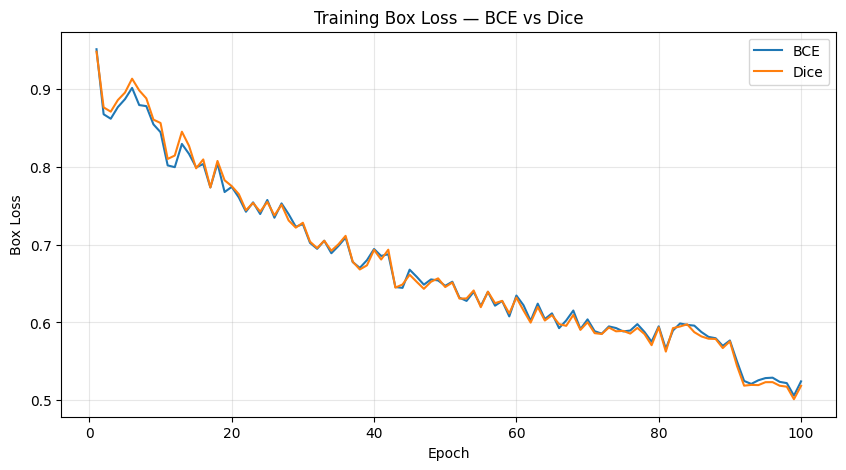

In [9]:
import matplotlib.pyplot as plt

epochs_bce = range(1, len(bce_history) + 1)
epochs_dice = range(1, len(dice_history) + 1)

plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["train/box_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["train/box_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Box Loss")
plt.title("Training Box Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

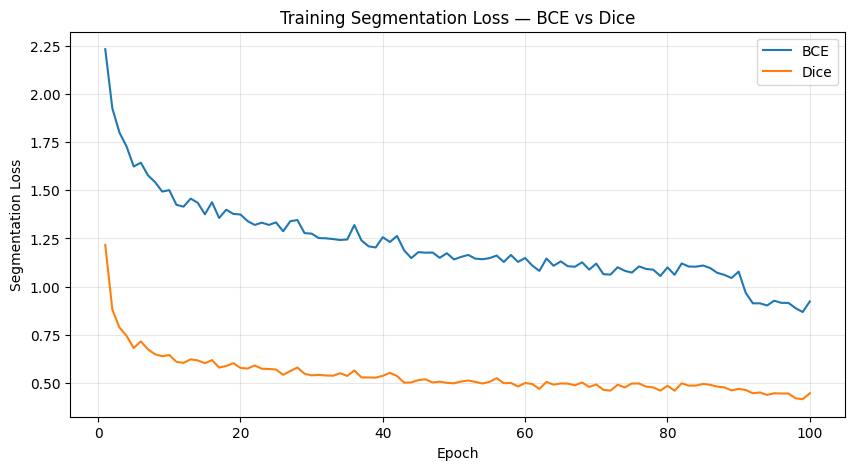

NOTE: BCE and Dice segmentation loss values use different mathematical scales and should not be compared directly.


In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["train/seg_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["train/seg_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Segmentation Loss")
plt.title("Training Segmentation Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(
    "NOTE: BCE and Dice segmentation loss values use different "
    "mathematical scales and should not be compared directly."
)

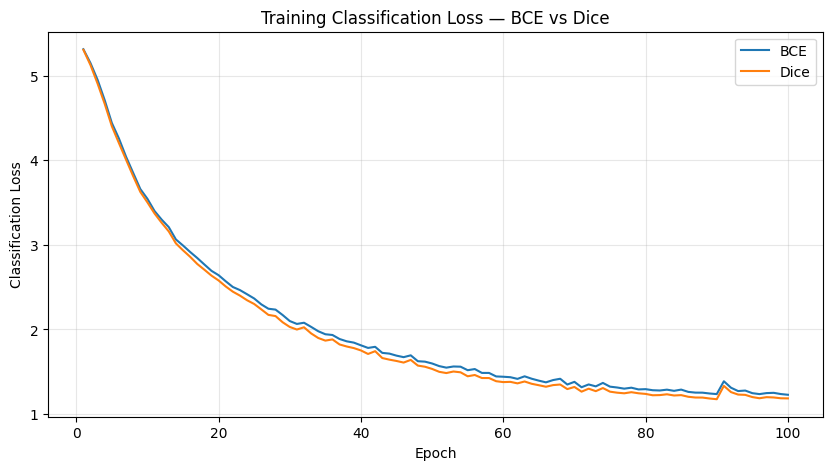

In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["train/cls_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["train/cls_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Classification Loss")
plt.title("Training Classification Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

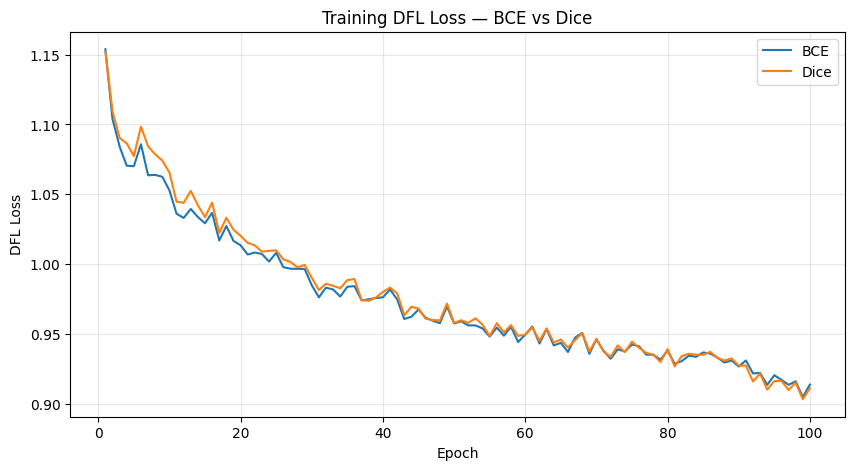

In [12]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["train/dfl_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["train/dfl_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("DFL Loss")
plt.title("Training DFL Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

# VAL LOSS



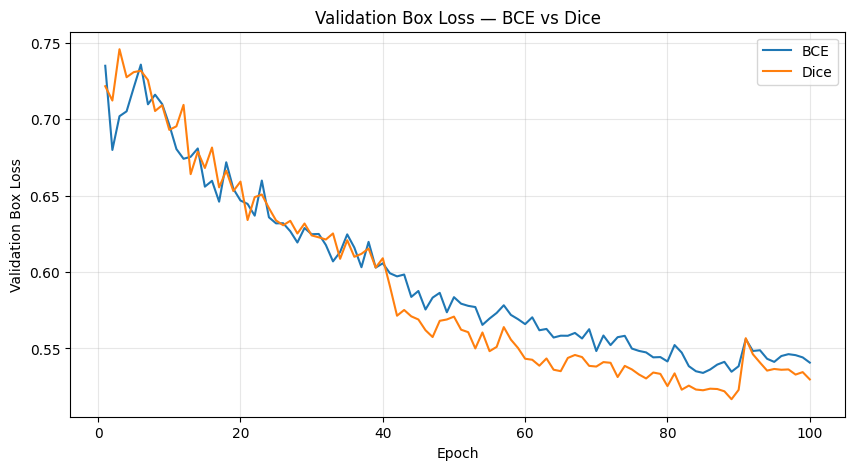

In [13]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["val/box_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["val/box_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Box Loss")
plt.title("Validation Box Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

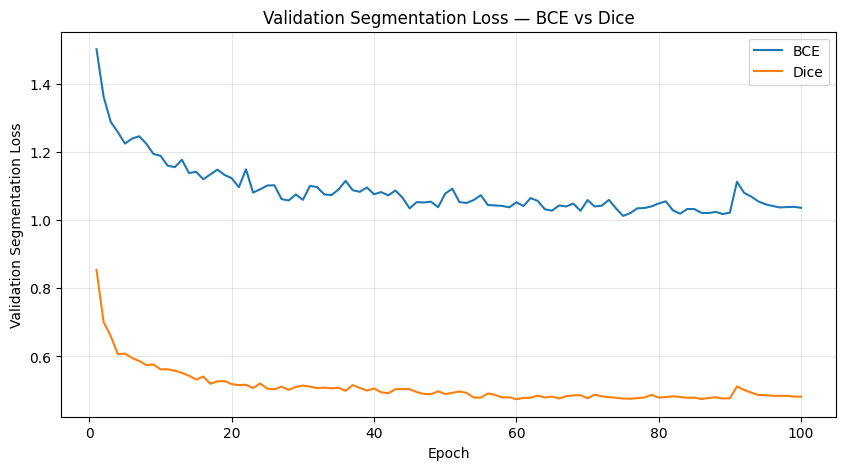

NOTE: The numerical magnitude of BCE and Dice segmentation loss cannot be directly compared because the formulas differ.


In [14]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["val/seg_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["val/seg_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Segmentation Loss")
plt.title("Validation Segmentation Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

print(
    "NOTE: The numerical magnitude of BCE and Dice segmentation "
    "loss cannot be directly compared because the formulas differ."
)

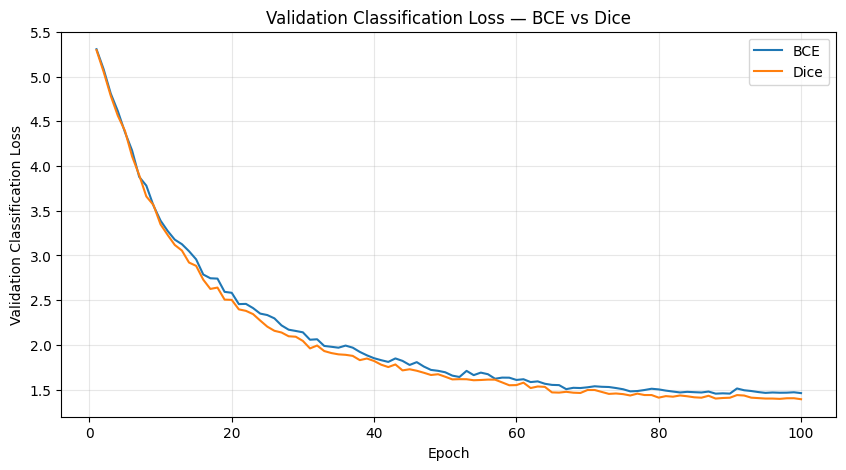

In [15]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["val/cls_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["val/cls_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Classification Loss")
plt.title("Validation Classification Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

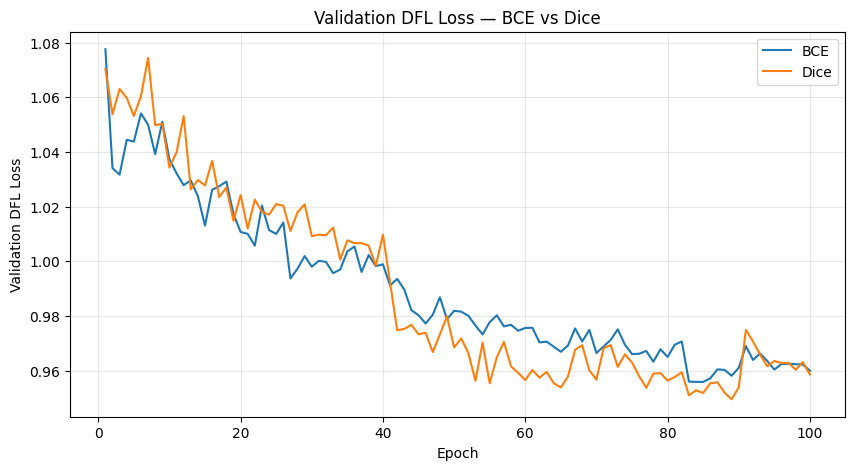

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(
    epochs_bce,
    bce_history["val/dfl_loss"],
    label="BCE"
)

plt.plot(
    epochs_dice,
    dice_history["val/dfl_loss"],
    label="Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Validation DFL Loss")
plt.title("Validation DFL Loss — BCE vs Dice")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 7. Confusion Matrix for All 109 Classes

A confusion matrix is generated for both the BCE and Dice Loss models using the same held-out test dataset.

The matrix includes:

- All **109 inventory classes**
- One additional **Background** category

The Background category is retained because object detection and instance segmentation models can produce:

- **False Positives (FP):** an object is predicted when no corresponding ground-truth object exists.
- **False Negatives (FN):** a ground-truth object exists but the model fails to detect it.

Therefore, the complete confusion matrix contains **110 × 110 cells**.

For readability, a large figure size is used so that all class names remain visible.

In [20]:
# ============================================================
# CELL — EXTRACT CONFUSION MATRICES
# BCE VS DICE
# 109 CLASSES + BACKGROUND
# ============================================================

import numpy as np
import torch


# ------------------------------------------------------------
# GET CONFUSION MATRIX FROM EVALUATION RESULTS
# ------------------------------------------------------------

bce_cm = bce_metrics.confusion_matrix.matrix
dice_cm = dice_metrics.confusion_matrix.matrix


# Convert to NumPy if stored as PyTorch tensor
if torch.is_tensor(bce_cm):
    bce_cm = bce_cm.detach().cpu().numpy()

if torch.is_tensor(dice_cm):
    dice_cm = dice_cm.detach().cpu().numpy()


# Make independent copies
bce_cm = np.array(bce_cm).copy()
dice_cm = np.array(dice_cm).copy()


# ------------------------------------------------------------
# GET ALL CLASS NAMES
# ------------------------------------------------------------

class_names = [
    bce_model.names[i]
    for i in range(len(bce_model.names))
]

labels = class_names + ["Background"]


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("=" * 75)
print("CONFUSION MATRIX CHECK")
print("=" * 75)

print(f"Number of inventory classes : {len(class_names)}")
print(f"Number of display labels     : {len(labels)}")

print()
print(f"BCE matrix shape             : {bce_cm.shape}")
print(f"Dice matrix shape            : {dice_cm.shape}")

print()

if len(class_names) == 109:
    print("✅ All 109 inventory classes loaded")
else:
    print(
        f"⚠️ Expected 109 inventory classes, "
        f"but found {len(class_names)}"
    )

if bce_cm.shape == (110, 110):
    print("✅ BCE matrix = 109 classes + Background")
else:
    print(
        f"⚠️ BCE matrix shape is {bce_cm.shape}, "
        "not the expected (110, 110)"
    )

if dice_cm.shape == (110, 110):
    print("✅ Dice matrix = 109 classes + Background")
else:
    print(
        f"⚠️ Dice matrix shape is {dice_cm.shape}, "
        "not the expected (110, 110)"
    )

print("=" * 75)

CONFUSION MATRIX CHECK
Number of inventory classes : 109
Number of display labels     : 110

BCE matrix shape             : (110, 110)
Dice matrix shape            : (110, 110)

✅ All 109 inventory classes loaded
✅ BCE matrix = 109 classes + Background
✅ Dice matrix = 109 classes + Background


### 7.1 BCE Model — Normalized Confusion Matrix

The confusion matrix for the BCE model is normalized according to the ground-truth class.

The matrix contains all **109 inventory classes** together with one additional **Background** category.

- The diagonal represents correct class predictions.
- Off-diagonal cells represent misclassification between inventory classes.
- The Background row represents missed ground-truth objects.
- The Background column represents unmatched or false-positive predictions.

Normalization allows classes with different numbers of test instances to be compared more fairly.

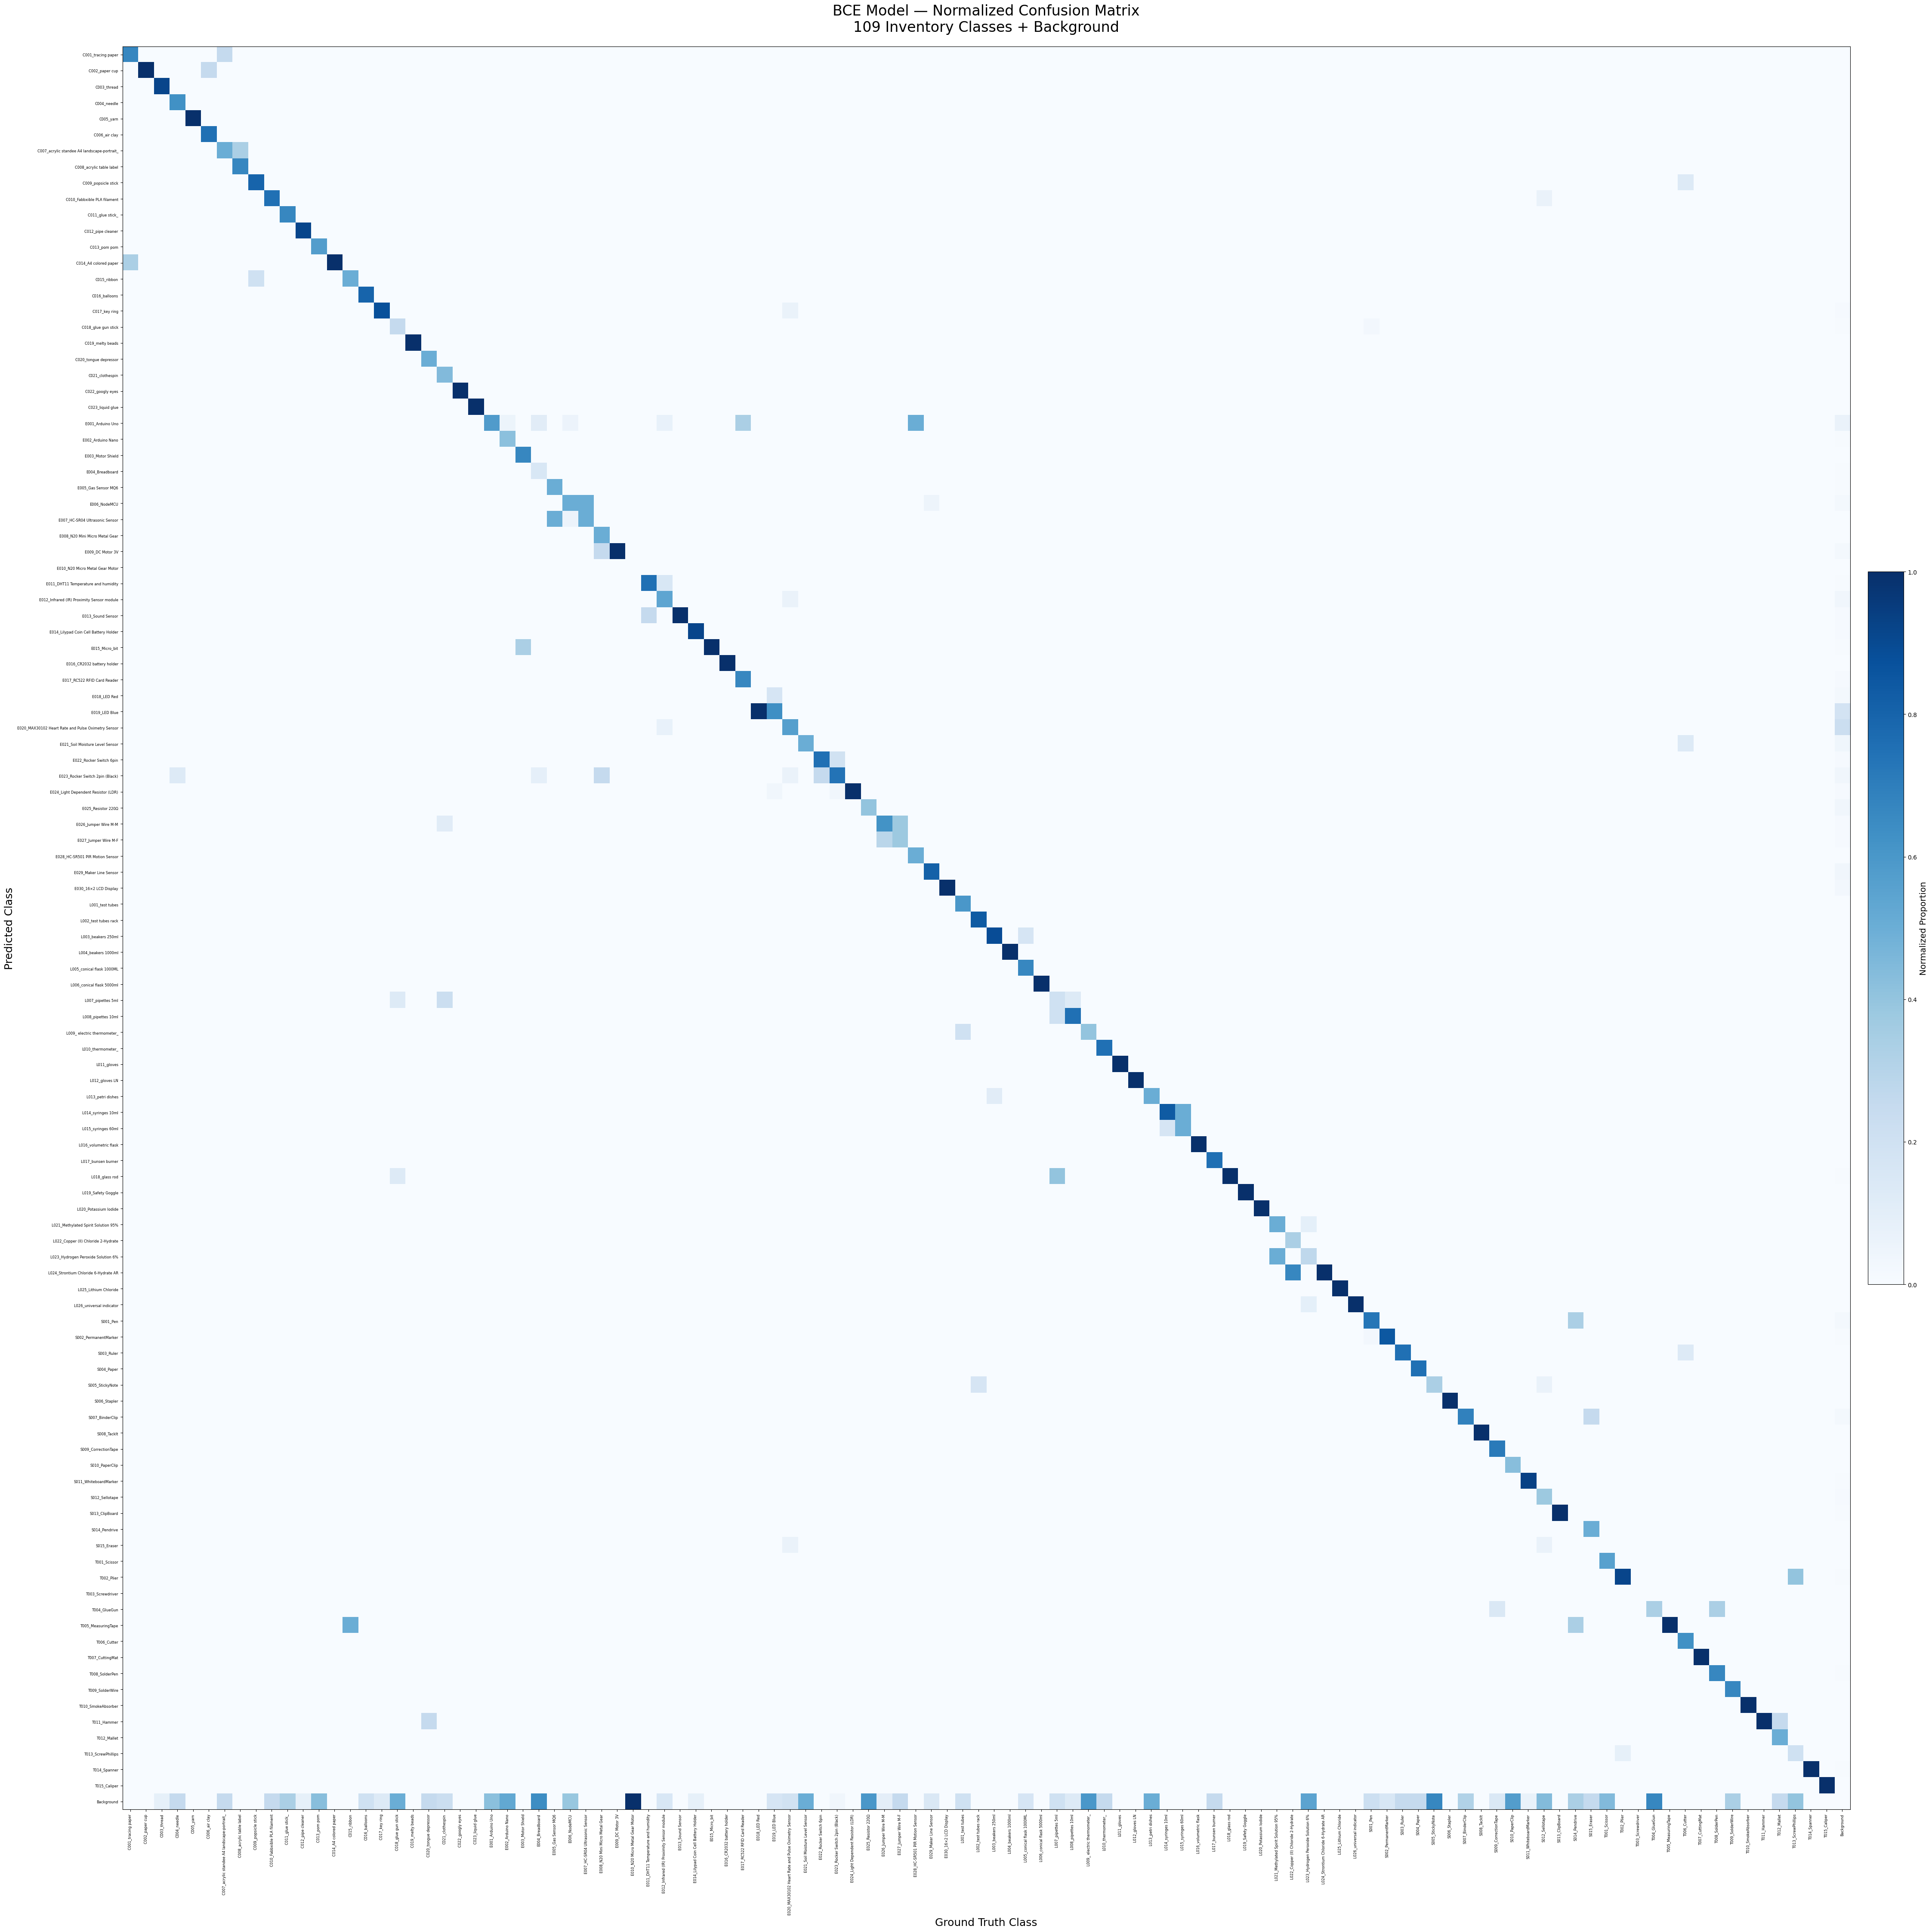

✅ BCE confusion matrix saved:
G:\AIIC\yolo_segmentation\evaluation\BCE_confusion_matrix_all_109_classes.png


In [22]:
# ============================================================
# BCE — NORMALIZED CONFUSION MATRIX
# ALL 109 CLASSES + BACKGROUND
# UPDATED BLUE COLOR MAP
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# NORMALIZE BY GROUND-TRUTH CLASS
# ------------------------------------------------------------

bce_column_sum = bce_cm.sum(
    axis=0,
    keepdims=True
)

bce_cm_normalized = np.divide(
    bce_cm,
    bce_column_sum,
    out=np.zeros_like(
        bce_cm,
        dtype=float
    ),
    where=bce_column_sum != 0
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(45, 45)
)

im = ax.imshow(
    bce_cm_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title(
    "BCE Model — Normalized Confusion Matrix\n"
    "109 Inventory Classes + Background",
    fontsize=24,
    pad=25
)

ax.set_xlabel(
    "Ground Truth Class",
    fontsize=18
)

ax.set_ylabel(
    "Predicted Class",
    fontsize=18
)

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    labels,
    fontsize=6
)

colorbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01
)

colorbar.set_label(
    "Normalized Proportion",
    fontsize=14
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

bce_cm_path = (
    evaluation_path
    / "BCE_confusion_matrix_all_109_classes.png"
)

plt.savefig(
    bce_cm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ BCE confusion matrix saved:")
print(bce_cm_path)

### 8.2 Dice Loss Model — Normalized Confusion Matrix

The Dice Loss model uses the same confusion matrix normalization and visualization settings as the BCE model.

Both confusion matrices use the same:

- 109 inventory classes
- Background category
- Test dataset
- Class ordering
- Normalization method
- Color scale from 0 to 1

This allows the confusion patterns of the two models to be compared directly.

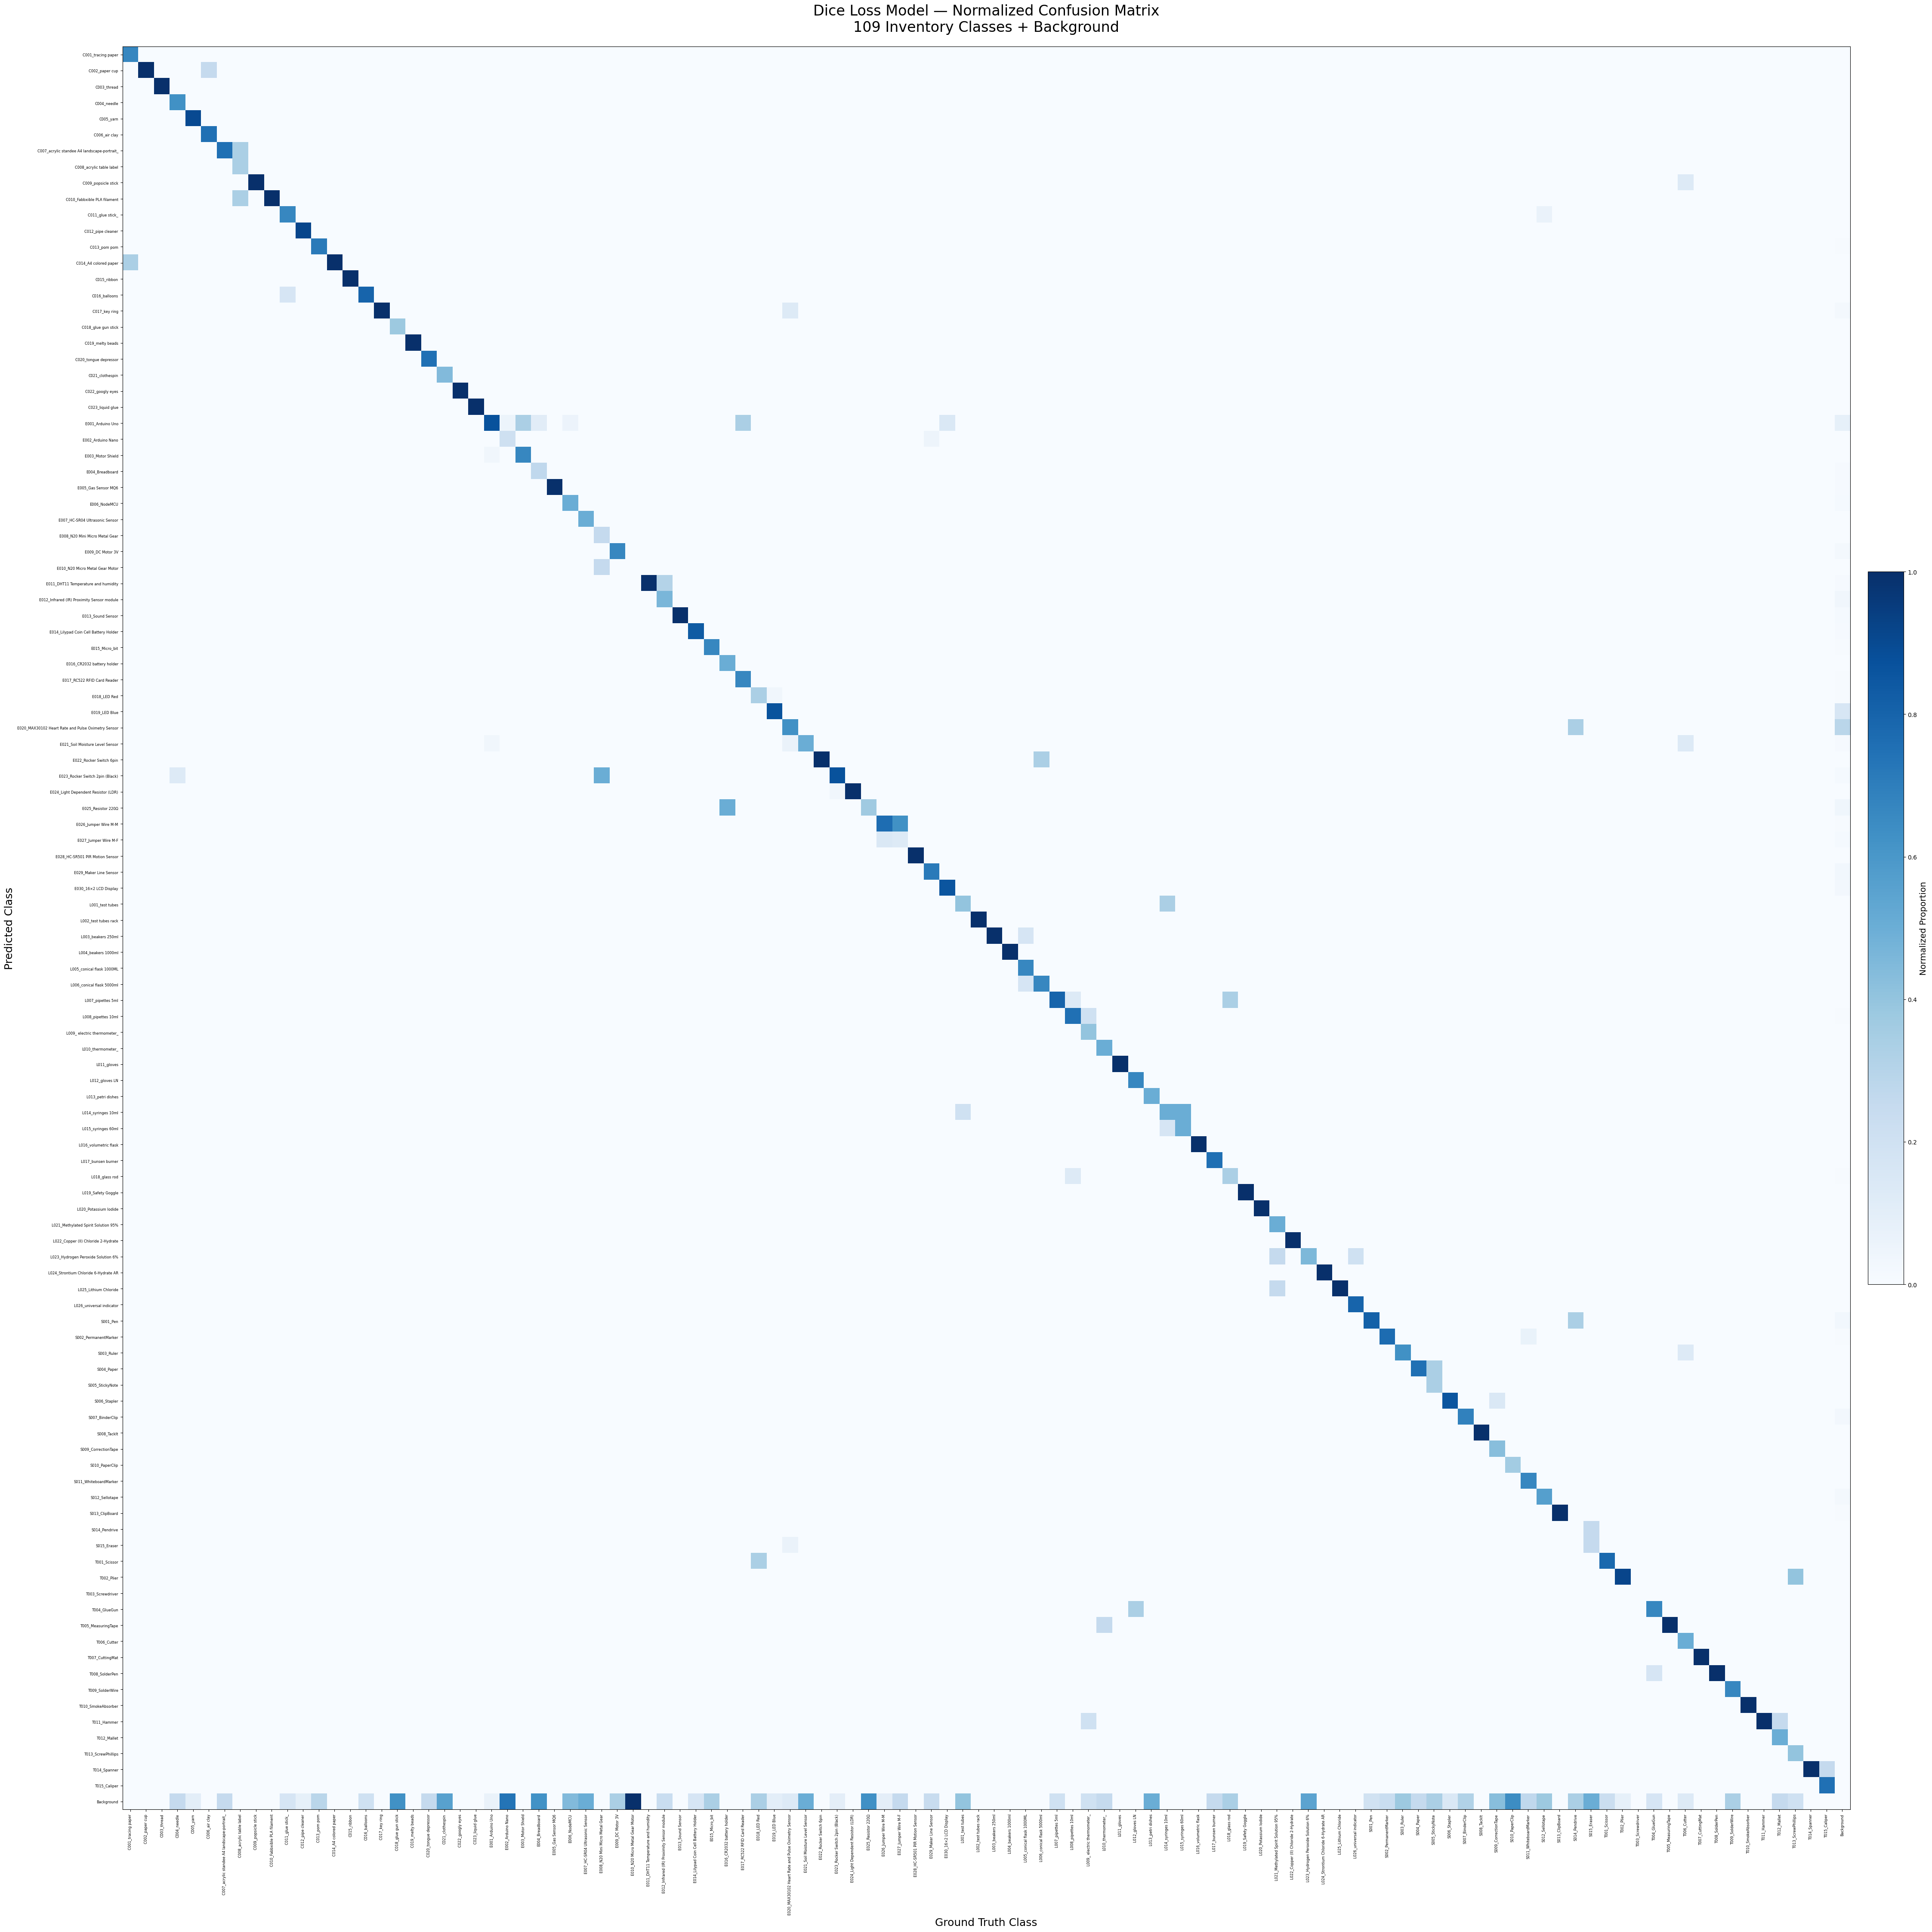

✅ Dice confusion matrix saved:
G:\AIIC\yolo_segmentation\evaluation\Dice_confusion_matrix_all_109_classes.png


In [23]:
# ============================================================
# DICE — NORMALIZED CONFUSION MATRIX
# ALL 109 CLASSES + BACKGROUND
# UPDATED BLUE COLOR MAP
# ============================================================

# ------------------------------------------------------------
# NORMALIZE BY GROUND-TRUTH CLASS
# ------------------------------------------------------------

dice_column_sum = dice_cm.sum(
    axis=0,
    keepdims=True
)

dice_cm_normalized = np.divide(
    dice_cm,
    dice_column_sum,
    out=np.zeros_like(
        dice_cm,
        dtype=float
    ),
    where=dice_column_sum != 0
)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(45, 45)
)

im = ax.imshow(
    dice_cm_normalized,
    cmap="Blues",
    vmin=0,
    vmax=1,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title(
    "Dice Loss Model — Normalized Confusion Matrix\n"
    "109 Inventory Classes + Background",
    fontsize=24,
    pad=25
)

ax.set_xlabel(
    "Ground Truth Class",
    fontsize=18
)

ax.set_ylabel(
    "Predicted Class",
    fontsize=18
)

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    labels,
    fontsize=6
)

colorbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01
)

colorbar.set_label(
    "Normalized Proportion",
    fontsize=14
)

plt.tight_layout()

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

dice_cm_path = (
    evaluation_path
    / "Dice_confusion_matrix_all_109_classes.png"
)

plt.savefig(
    dice_cm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Dice confusion matrix saved:")
print(dice_cm_path)

### 7.3 BCE vs Dice Confusion Matrix Difference

This matrix shows the difference between the normalized Dice and BCE confusion matrices.

$$
Difference = Dice - BCE
$$

For diagonal cells:

- Positive value = Dice correctly classified more instances.
- Negative value = BCE correctly classified more instances.

For off-diagonal cells:

- Positive value = Dice produced more confusion for that class pair.
- Negative value = Dice reduced the confusion compared with BCE.

This matrix uses all 109 inventory classes and the Background category.

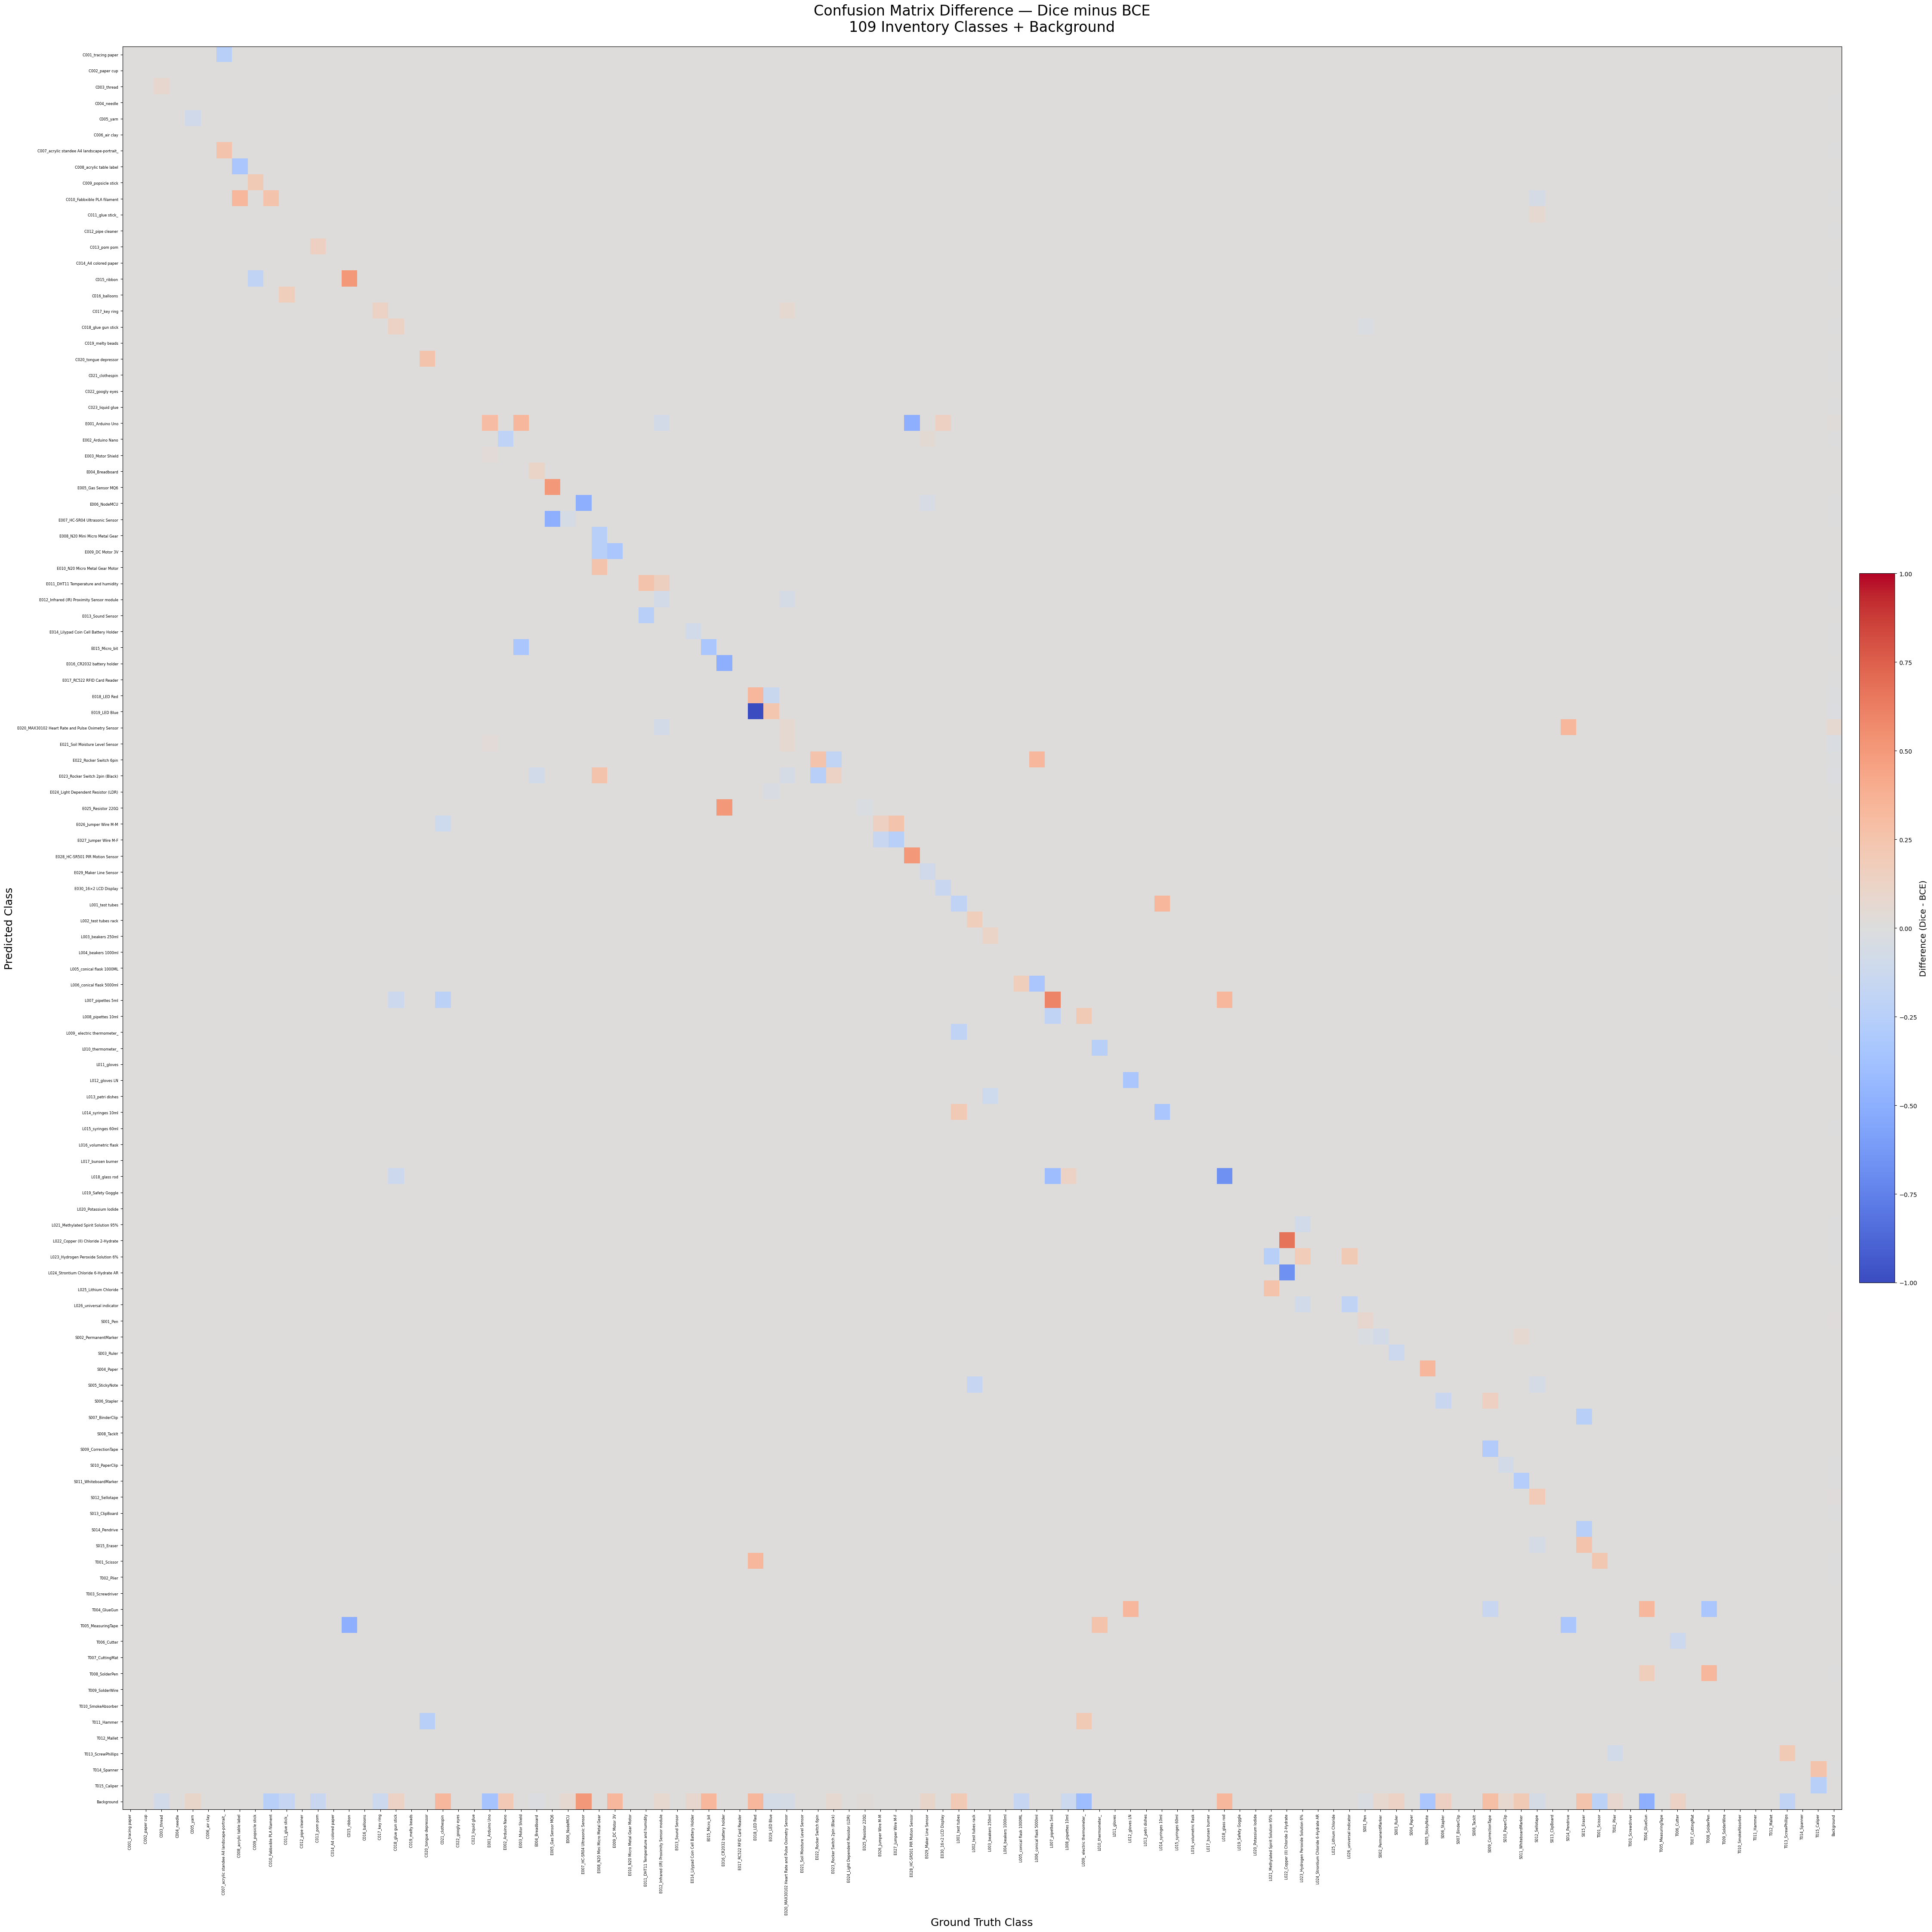

✅ Difference confusion matrix saved:
G:\AIIC\yolo_segmentation\evaluation\Dice_vs_BCE_confusion_matrix_difference.png


In [24]:
# ============================================================
# BCE VS DICE — CONFUSION MATRIX DIFFERENCE
# ALL 109 CLASSES + BACKGROUND
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

cm_difference = (
    dice_cm_normalized
    - bce_cm_normalized
)

# Symmetrical scale around zero
max_abs = np.max(np.abs(cm_difference))

fig, ax = plt.subplots(
    figsize=(45, 45)
)

im = ax.imshow(
    cm_difference,
    cmap="coolwarm",
    vmin=-max_abs,
    vmax=max_abs,
    aspect="auto",
    interpolation="nearest"
)

ax.set_title(
    "Confusion Matrix Difference — Dice minus BCE\n"
    "109 Inventory Classes + Background",
    fontsize=24,
    pad=25
)

ax.set_xlabel(
    "Ground Truth Class",
    fontsize=18
)

ax.set_ylabel(
    "Predicted Class",
    fontsize=18
)

ax.set_xticks(
    np.arange(len(labels))
)

ax.set_yticks(
    np.arange(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=90,
    fontsize=6
)

ax.set_yticklabels(
    labels,
    fontsize=6
)

colorbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.02,
    pad=0.01
)

colorbar.set_label(
    "Difference (Dice - BCE)",
    fontsize=14
)

plt.tight_layout()

difference_cm_path = (
    evaluation_path
    / "Dice_vs_BCE_confusion_matrix_difference.png"
)

plt.savefig(
    difference_cm_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("✅ Difference confusion matrix saved:")
print(difference_cm_path)

In [25]:
# ============================================================
# TEXT SUMMARY — CONFUSION MATRIX DIFFERENCE
# ============================================================

import pandas as pd
import numpy as np

# Only use the 109 inventory classes
# Background is excluded from this class-level summary
diagonal_difference = np.diag(cm_difference)[:109]

class_difference_df = pd.DataFrame({
    "Class": class_names,
    "Correct Prediction Difference": diagonal_difference
})

# Sort from strongest Dice improvement to strongest BCE advantage
class_difference_df = class_difference_df.sort_values(
    "Correct Prediction Difference",
    ascending=False
).reset_index(drop=True)


# ------------------------------------------------------------
# TOP IMPROVEMENTS FROM DICE
# ------------------------------------------------------------

dice_improved = class_difference_df[
    class_difference_df["Correct Prediction Difference"] > 0
].head(10)


# ------------------------------------------------------------
# CLASSES WHERE BCE WAS BETTER
# ------------------------------------------------------------

bce_better = class_difference_df[
    class_difference_df["Correct Prediction Difference"] < 0
].sort_values(
    "Correct Prediction Difference"
).head(10)


# ------------------------------------------------------------
# OVERALL COUNTS
# ------------------------------------------------------------

num_dice_better = (
    diagonal_difference > 0
).sum()

num_bce_better = (
    diagonal_difference < 0
).sum()

num_equal = (
    np.isclose(
        diagonal_difference,
        0
    )
).sum()


print("=" * 75)
print("CONFUSION MATRIX DIFFERENCE SUMMARY")
print("=" * 75)

print()
print(
    f"Classes improved with Dice : {num_dice_better}"
)

print(
    f"Classes better with BCE    : {num_bce_better}"
)

print(
    f"Classes approximately equal: {num_equal}"
)

print()


print("=" * 75)
print("TOP 10 CLASSES IMPROVED BY DICE")
print("=" * 75)

if len(dice_improved) > 0:
    for _, row in dice_improved.iterrows():

        print(
            f"{row['Class']}: "
            f"+{row['Correct Prediction Difference']:.3f}"
        )

else:
    print("No positive diagonal improvements found.")


print()
print("=" * 75)
print("TOP 10 CLASSES WHERE BCE PERFORMED BETTER")
print("=" * 75)

if len(bce_better) > 0:
    for _, row in bce_better.iterrows():

        print(
            f"{row['Class']}: "
            f"{row['Correct Prediction Difference']:.3f}"
        )

else:
    print("No classes where BCE performed better.")

CONFUSION MATRIX DIFFERENCE SUMMARY

Classes improved with Dice : 32
Classes better with BCE    : 28
Classes approximately equal: 49

TOP 10 CLASSES IMPROVED BY DICE
L022_Copper (II) Chloride 2-Hydrate: +0.667
L007_pipettes 5ml: +0.600
E028_HC-SR501 PIR Motion Sensor: +0.500
E005_Gas Sensor MQ6: +0.500
C015_ribbon: +0.500
T008_SolderPen: +0.333
E018_LED Red: +0.333
T004_GlueGun: +0.333
E001_Arduino Uno: +0.290
C010_Fabbxible PLA filament: +0.250

TOP 10 CLASSES WHERE BCE PERFORMED BETTER
L018_glass rod: -0.667
E016_CR2032 battery holder: -0.500
E015_Micro_bit: -0.333
L012_gloves LN: -0.333
L014_syringes 10ml: -0.333
E009_DC Motor 3V: -0.333
L006_conical flask 5000ml: -0.333
C008_acrylic table label: -0.333
S009_CorrectionTape: -0.286
S011_WhiteboardMarker: -0.267


### 7.4 Class-Level Confusion Difference with Test Support

The class-level difference analysis is extended by including the number of ground-truth instances available for each class in the test set.

The difference is calculated as:

$$
Difference = Dice - BCE
$$

For diagonal cells, a positive value means that Dice achieved a higher proportion of correct predictions for that class, while a negative value means that BCE performed better.

The **Test Instances** column is important because a large difference for a class with only a few test instances may be caused by only one or two additional correct predictions.

Therefore, class-level differences should be interpreted together with the number of test instances and not used alone to determine overall model performance.

In [26]:
# ============================================================
# CLASS-LEVEL CONFUSION DIFFERENCE
# WITH TEST INSTANCE SUPPORT
# ============================================================

import pandas as pd
import numpy as np


# ------------------------------------------------------------
# 1. DIAGONAL DIFFERENCE
#    Dice normalized CM - BCE normalized CM
# ------------------------------------------------------------

diagonal_difference = np.diag(
    cm_difference
)[:109]


# ------------------------------------------------------------
# 2. NUMBER OF GROUND-TRUTH TEST INSTANCES PER CLASS
#
# Columns = Ground Truth
# Rows    = Predicted
#
# Sum each GT column, including the Background prediction row,
# so missed objects are also counted.
# ------------------------------------------------------------

test_instances = (
    bce_cm[:, :109]
    .sum(axis=0)
    .astype(int)
)


# ------------------------------------------------------------
# 3. BUILD CLASS-LEVEL TABLE
# ------------------------------------------------------------

class_difference_df = pd.DataFrame({
    "Class": class_names,
    "Test Instances": test_instances,
    "Correct Prediction Difference": diagonal_difference
})


# Sort from strongest Dice improvement
# to strongest BCE advantage
class_difference_df = (
    class_difference_df
    .sort_values(
        "Correct Prediction Difference",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 4. TOP CLASSES IMPROVED BY DICE
# ------------------------------------------------------------

dice_improved = (
    class_difference_df[
        class_difference_df[
            "Correct Prediction Difference"
        ] > 0
    ]
    .head(10)
)


# ------------------------------------------------------------
# 5. TOP CLASSES WHERE BCE WAS BETTER
# ------------------------------------------------------------

bce_better = (
    class_difference_df[
        class_difference_df[
            "Correct Prediction Difference"
        ] < 0
    ]
    .sort_values(
        "Correct Prediction Difference",
        ascending=True
    )
    .head(10)
)


# ------------------------------------------------------------
# 6. OVERALL CLASS COUNTS
# ------------------------------------------------------------

num_dice_better = (
    diagonal_difference > 0
).sum()

num_bce_better = (
    diagonal_difference < 0
).sum()

num_equal = np.isclose(
    diagonal_difference,
    0
).sum()


# ------------------------------------------------------------
# 7. PRINT SUMMARY
# ------------------------------------------------------------

print("=" * 85)
print("CONFUSION MATRIX DIFFERENCE SUMMARY")
print("=" * 85)

print(
    f"Classes improved with Dice  : {num_dice_better}"
)

print(
    f"Classes better with BCE     : {num_bce_better}"
)

print(
    f"Classes approximately equal : {num_equal}"
)


# ------------------------------------------------------------
# TOP 10 — DICE
# ------------------------------------------------------------

print()
print("=" * 85)
print("TOP 10 CLASSES IMPROVED BY DICE")
print("=" * 85)

if len(dice_improved) > 0:

    for _, row in dice_improved.iterrows():

        print(
            f"{row['Class']:<45} "
            f"| Test Instances: {int(row['Test Instances']):>3} "
            f"| Difference: "
            f"+{row['Correct Prediction Difference']:.3f}"
        )

else:
    print("No positive diagonal improvements found.")


# ------------------------------------------------------------
# TOP 10 — BCE
# ------------------------------------------------------------

print()
print("=" * 85)
print("TOP 10 CLASSES WHERE BCE PERFORMED BETTER")
print("=" * 85)

if len(bce_better) > 0:

    for _, row in bce_better.iterrows():

        print(
            f"{row['Class']:<45} "
            f"| Test Instances: {int(row['Test Instances']):>3} "
            f"| Difference: "
            f"{row['Correct Prediction Difference']:.3f}"
        )

else:
    print("No classes where BCE performed better.")

CONFUSION MATRIX DIFFERENCE SUMMARY
Classes improved with Dice  : 32
Classes better with BCE     : 28
Classes approximately equal : 49

TOP 10 CLASSES IMPROVED BY DICE
L022_Copper (II) Chloride 2-Hydrate           | Test Instances:   3 | Difference: +0.667
L007_pipettes 5ml                             | Test Instances:   5 | Difference: +0.600
E028_HC-SR501 PIR Motion Sensor               | Test Instances:   2 | Difference: +0.500
E005_Gas Sensor MQ6                           | Test Instances:   2 | Difference: +0.500
C015_ribbon                                   | Test Instances:   4 | Difference: +0.500
T008_SolderPen                                | Test Instances:   3 | Difference: +0.333
E018_LED Red                                  | Test Instances:   3 | Difference: +0.333
T004_GlueGun                                  | Test Instances:   6 | Difference: +0.333
E001_Arduino Uno                              | Test Instances:  31 | Difference: +0.290
C010_Fabbxible PLA filament    